<h1> Visualization: Which city got freaked-out the most if someone is not wearing a face mask? </h1>
<p> This project uses data from the World COVID-19 Pandemic and Citizen Life Survey, part of a research project that I participated in when I was a graduate research assistant at Seoul National University. The following codes exhibit how I process the data for visualization and visualize it. I have excluded some more detailed processes such as checking the values because I intended to make this presentation look concise. For people who are only interested in the result, please scroll down to the bottom and check the interpretation section. </p>

<h2> Data Pre-processing </h2>

In [1]:
import pandas as pd
import numpy as np
import pyreadstat
import math

import matplotlib.pyplot as plt

In [2]:
path = #... location of raw data
df, meta = pyreadstat.read_sav(path, usecols=['SQ1', 'qV_3'])

In [3]:
cities = ['Seoul', 'Daegu', 'Tokyo', 'Osaka', 'Taipei', 'Hong Kong', 'Singapore', 'New York', 'Los Angeles', 'Toronto', 'London', 'Berlin', 'Paris',
                'Vienna', 'Madrid', 'Rome', 'Lisbon', 'Cape Town', 'Stockholm', 'Oslo', 'Moscow', 'Sydney', 'Wellington', 'Manila', 'Sao Paulo',
                'Buenos Aires', 'Santiago', 'Mexico City', 'New Delhi', 'Jakarta']

def city_dic(x):    
    city = cities[int(x)-1]
    return(city)

df['city'] = df['SQ1'].apply(lambda x: city_dic(x))

In [4]:
vc = df.groupby('city')['qV_3'].value_counts(normalize=True).sort_index()
vc = vc.unstack()

vc['rank_base'] = vc[1.0] + vc[2.0]

vc = vc.sort_values(by='rank_base')

<h3> the following cell presents a snippet of the table after pre-processing </h3>

In [5]:
vc.head()

qV_3,1.0,2.0,3.0,4.0,rank_base
city,,,,,
Oslo,0.145129,0.333996,0.318091,0.202783,0.479125
Stockholm,0.112500,0.383929,0.266071,0.237500,0.496429
Berlin,0.191235,0.348606,0.235060,0.225100,0.539841
Moscow,0.161034,0.381710,0.242545,0.214712,0.542744
Vienna,0.121094,0.423828,0.232422,0.222656,0.544922


<h3> code that retreves data in the structure suitable for visualization </h3>

In [6]:
result_dic = dict()

for city in vc.index:
    
    city_name = str(city)
    
    city = vc.loc[city].to_list()[:4]
    city = [round(i, 4) for i in city]

    category_names = ["Very Anxious",
                    'A Little Anxious',
                    'Not Very Anxious',
                    'Not Anxious at All']
        
    result_dic[city_name] = city

<h2> Visualization </h2>

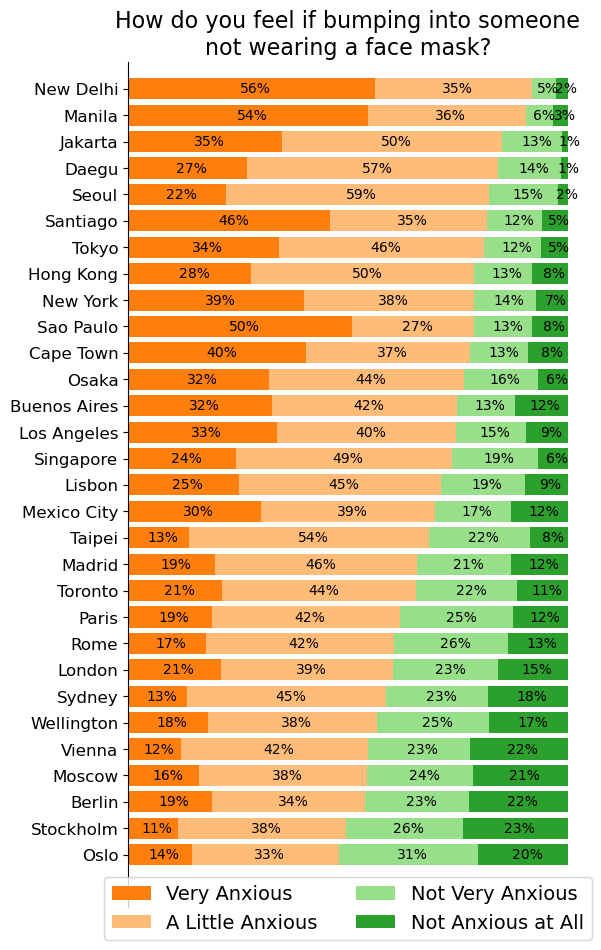

In [7]:
def survey(results, category_names):
        
        labels = list(results.keys())
    
        data = np.array(list(results.values()))*100
        data_cum = data.cumsum(axis=1)
            
        cmap = plt.get_cmap('tab20')
        category_colors = cmap([2, 3, 5, 4])
            
        fig, ax = plt.subplots(figsize=(6,9))
        
        ax.invert_xaxis()
        ax.xaxis.set_visible(False)
        ax.set_xlim(0, np.sum(data, axis=1).max())
        
        ax.set_ylim([-2, 30])
        ax.tick_params(axis='y', labelsize=12)
            
        for i, (colname, color) in enumerate(zip(category_names, category_colors)):
            
                
            widths = data[:, i]
            starts = data_cum[:, i] - widths
            rects = ax.barh(labels, widths, left=starts, height=0.8,
                                label=colname, color=color)
            
            ax.bar_label(rects, fmt='%i%%',label_type='center', color='black', padding=3)
            
            
        ax.legend(ncol=2, loc='lower center', bbox_to_anchor=(0.5, -0.05), fontsize=14)
        
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
            
        return(fig, ax)
    
    
fig, ax = survey(result_dic, category_names)
fig.tight_layout()

ax.set_title('How do you feel if bumping into someone\nnot wearing a face mask?', fontsize=16)
        
#plt.savefig('portfo1.png', dpi=300, bbox_inches = "tight")
plt.show()

<h2> Interpretation </h2>

<p> 1. The figure presents the rank of the proportion of samples who would feel anxious if seeing someone not wearing a face mask in each city in a descending manner from the top to the bottom. New Delhi had the greatest proportion of samples (91%) who would feel anxious if they see someone not wearing a face mask, while Oslo had the smallest (47%). </p>
<p> 2. The result was in accordance with the general understanding that Asian cities (New Delhi, Manila, Seoul, Tokyo, etc.) saw wearing a face mask as essential to the pandemic management while European cities (Oslo, Stockholm, Berlin, Rome, etc.) thought differently. </p>
<p> 3. The result was interesting in that American cities (New York and Los Angeles) had a great proportion of samples (77% and 73%) that agreed with the importance of wearing a face mask in pandemic management, as in Korean media during the pandemic, Americans were generalized and portrayed as anti-face-mask for most of the times. </p>